# SA_AutoLabel — Auto-Labeling Sentiment Dataset

Notebook ini melakukan **auto-labeling** pada ulasan yang belum berlabel menggunakan pre-trained model `mdhugol/indonesia-bert-sentiment-classification` (IndoBERT fine-tuned untuk review Indonesia, 3-class: positive/neutral/negative).

### Input

**Opsi A (Data asli):** `data/raw_review/Overall_All Data_for_Prediction.xlsx` (9,719 baris, 6 sheet)

**Opsi B (Desa wisata baru):** Taruh file CSV di `data/raw_review/additional/`. Format:
- `review` (wajib) — teks ulasan mentah
- `nama desa wisata` (opsional) — nama desa; jika tidak ada, diambil dari nama file
- `cleaned_review` (opsional) — teks bersih; jika tidak ada, auto-clean
- `label` (opsional) — label sentimen (0/1/2); jika tidak ada, auto-label oleh IndoBERT

### Output
`sentiment analysis/data/sentiment_labeled.csv` + 4 file JSON untuk dashboard

Label scheme: `0 = Negatif`, `1 = Positif`, `2 = Netral`

## 0. Setup

In [1]:
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import pipeline, AutoModelForSequenceClassification, AutoTokenizer

# Path setup — notebook berjalan dari 'sentiment analysis/'
BASE_DIR   = os.path.dirname(os.getcwd())  # TA_Notebook/
EXCEL_PATH = os.path.join(BASE_DIR, 'data', 'raw_review', 'Overall_All Data_for_Prediction.xlsx')
OUT_DIR    = os.path.join(os.getcwd(), 'data')
OUT_PATH   = os.path.join(OUT_DIR, 'sentiment_labeled.csv')

# Directory untuk CSV tambahan (desa wisata baru)
ADDITIONAL_DIR = os.path.join(BASE_DIR, 'data', 'raw_review', 'additional', 'cleaned')

os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(ADDITIONAL_DIR, exist_ok=True)

SHEETS = ['Kampung_Blekok', 'Umbul_Ponggok', 'Pujon_Kidul',
          'Pentingsari', 'Penglipuran', 'Kete_Kesu']

# Label mapping dataset: 0=Negatif, 1=Positif, 2=Netral
LABEL_NAME = {0: 'Negatif', 1: 'Positif', 2: 'Netral'}
COLORS     = {'Positif': '#2ecc71', 'Negatif': '#e74c3c', 'Netral': '#3498db'}

print(f'EXCEL_PATH     : {EXCEL_PATH}')
print(f'ADDITIONAL_DIR : {ADDITIONAL_DIR}')
print(f'OUT_PATH       : {OUT_PATH}')

EXCEL_PATH     : d:\Kuliah\TA\TA_Notebook\data\raw_review\Overall_All Data_for_Prediction.xlsx
ADDITIONAL_DIR : d:\Kuliah\TA\TA_Notebook\data\raw_review\additional\cleaned
OUT_PATH       : d:\Kuliah\TA\TA_Notebook\sentiment analysis\data\sentiment_labeled.csv


## 1. Load Dataset

In [2]:
# ── Load dari Excel (data asli) ──
dfs = []
if os.path.exists(EXCEL_PATH):
    for sheet in SHEETS:
        df = pd.read_excel(EXCEL_PATH, sheet_name=sheet)
        df['sheet'] = sheet
        dfs.append(df)
    print(f'Loaded {sum(len(d) for d in dfs)} rows from Excel ({len(SHEETS)} sheets)')
else:
    print(f'Excel file not found at {EXCEL_PATH}, skipping')

# ── Load dari CSV tambahan (desa wisata baru) ──
# Format CSV: kolom "review" (wajib) + "nama desa wisata" (opsional, diambil dari nama file jika kosong)
# Kolom opsional: "cleaned_review", "label"
additional_csvs = sorted([f for f in os.listdir(ADDITIONAL_DIR)
                          if f.endswith('.csv') and '_full.csv' not in f])
if additional_csvs:
    print(f'\nFound {len(additional_csvs)} additional CSV(s):')
    for csv_file in additional_csvs:
        csv_path = os.path.join(ADDITIONAL_DIR, csv_file)
        csv_df = pd.read_csv(csv_path, encoding='utf-8')

        if 'review' not in csv_df.columns:
            print(f'  WARNING: {csv_file} missing "review" column, skipping')
            continue

        # Auto-fill village name if missing
        if 'nama desa wisata' not in csv_df.columns:
            name = csv_file.replace('_reviews', '').replace('.csv', '').replace('_', ' ')
            csv_df['nama desa wisata'] = name

        # Create cleaned_review if missing
        if 'cleaned_review' not in csv_df.columns:
            def basic_clean(text):
                text = str(text).lower().strip()
                text = re.sub(r'[^\w\s]', ' ', text)
                text = re.sub(r'\s+', ' ', text).strip()
                return text
            csv_df['cleaned_review'] = csv_df['review'].apply(basic_clean)

        # Mark all as unlabeled if no label column
        if 'label' not in csv_df.columns:
            csv_df['label'] = np.nan

        csv_df['sheet'] = csv_file
        dfs.append(csv_df)
        village = csv_df['nama desa wisata'].iloc[0]
        print(f'  {csv_file}: {len(csv_df)} rows ({village})')
else:
    print(f'\nNo additional CSVs found in {ADDITIONAL_DIR}')

all_df = pd.concat(dfs, ignore_index=True)

print(f'\nTotal rows: {len(all_df)}')
print(f'Columns   : {all_df.columns.tolist()}')
print()
print('Rows per desa wisata:')
print(all_df['nama desa wisata'].value_counts())

Loaded 9719 rows from Excel (6 sheets)

Found 3 additional CSV(s):
  osing_reviews.csv: 91 rows (Osing)
  pentingsari_reviews.csv: 121 rows (Pentingsari)
  pulesari_reviews.csv: 145 rows (Pulesari)

Total rows: 10076
Columns   : ['review', 'cleaned_review', 'label', 'note', 'nama desa wisata', 'sheet']

Rows per desa wisata:
nama desa wisata
penglipuran       2904
pujonkidul        2204
umbul ponggok     2019
kete kesu         1608
kampung blekok     533
pentingsari        451
Pulesari           145
Pentingsari        121
Osing               91
Name: count, dtype: int64


## 2. Identifikasi Labeled vs Unlabeled

In [3]:
def is_unlabeled(val):
    """Cek apakah label kosong/invalid."""
    s = str(val).strip()
    return s in ['', 'nan', ' ', 'inference'] or pd.isna(val)

mask_unlabeled = all_df['label'].apply(is_unlabeled)

n_labeled   = (~mask_unlabeled).sum()
n_unlabeled = mask_unlabeled.sum()

print(f'Total     : {len(all_df)}')
print(f'Labeled   : {n_labeled} ({n_labeled/len(all_df)*100:.1f}%)')
print(f'Unlabeled : {n_unlabeled} ({n_unlabeled/len(all_df)*100:.1f}%)')
print()
print('Labeled per desa wisata:')
labeled_per_desa = all_df[~mask_unlabeled].groupby('nama desa wisata').size()
print(labeled_per_desa)

Total     : 10076
Labeled   : 2881 (28.6%)
Unlabeled : 7195 (71.4%)

Labeled per desa wisata:
nama desa wisata
kampung blekok    523
kete kesu         480
penglipuran       567
pentingsari       261
pujonkidul        571
umbul ponggok     479
dtype: int64


In [4]:
# Model: mdhugol/indonesia-bert-sentiment-classification
# LABEL_0=positive, LABEL_1=neutral, LABEL_2=negative
HF_LABEL_MAP = {
    'LABEL_0': 1,  # positive -> Positif
    'LABEL_1': 2,  # neutral  -> Netral
    'LABEL_2': 0,  # negative -> Negatif
}

pretrained = 'mdhugol/indonesia-bert-sentiment-classification'
model_sa = AutoModelForSequenceClassification.from_pretrained(pretrained)
tokenizer_sa = AutoTokenizer.from_pretrained(pretrained)
classifier = pipeline("sentiment-analysis", model=model_sa, tokenizer=tokenizer_sa)
print('Model loaded.')

# Test prediksi
test_reviews = [
    'tempatnya sangat indah dan menyenangkan',
    'pelayanan buruk dan mengecewakan',
    'biasa saja tidak ada yang spesial',
]
test_results = classifier(test_reviews)
print('Test prediksi:')
for rev, res in zip(test_reviews, test_results):
    label_num = HF_LABEL_MAP[res['label']]
    print(f'  [{LABEL_NAME[label_num]:7s} | score={res["score"]:.3f}] {rev}')

d:\miniconda3\envs\ta_nlp\lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
d:\miniconda3\envs\ta_nlp\lib\site-packages\transformers\modeling_utils.py:446: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.s

Model loaded.
Test prediksi:
  [Positif | score=0.998] tempatnya sangat indah dan menyenangkan
  [Negatif | score=0.998] pelayanan buruk dan mengecewakan
  [Negatif | score=0.996] biasa saja tidak ada yang spesial


## 4. Auto-Label Baris yang Belum Berlabel

In [5]:
# Ambil teks yang belum berlabel
texts_to_label = all_df.loc[mask_unlabeled, 'cleaned_review'].fillna('').tolist()
texts_to_label = [t if t.strip() else 'tidak ada ulasan' for t in texts_to_label]

print(f'Melabel {len(texts_to_label)} baris...')

# Prediksi dalam batch
BATCH_SIZE = 32
results = classifier(
    texts_to_label,
    batch_size=BATCH_SIZE,
    truncation=True,
    max_length=128,
)

# Assign label
auto_labels = [HF_LABEL_MAP[r['label']] for r in results]
auto_scores = [r['score'] for r in results]

all_df.loc[mask_unlabeled, 'label']       = auto_labels
all_df.loc[mask_unlabeled, 'conf_score']  = auto_scores
all_df.loc[mask_unlabeled, 'label_source'] = 'auto'

# Label yang sudah ada (manual)
all_df.loc[~mask_unlabeled, 'label']       = pd.to_numeric(all_df.loc[~mask_unlabeled, 'label'], errors='coerce')
all_df.loc[~mask_unlabeled, 'conf_score']  = 1.0
all_df.loc[~mask_unlabeled, 'label_source'] = 'manual'

# Konversi label ke int
all_df['label'] = all_df['label'].astype(float).astype(int)

print('Auto-labeling selesai.')
print(f'\nDistribusi label (semua data):')
print(all_df['label'].map(LABEL_NAME).value_counts())

Melabel 7195 baris...
Auto-labeling selesai.

Distribusi label (semua data):
label
Positif    8996
Negatif     626
Netral      454
Name: count, dtype: int64


## 5. Verifikasi & Statistik

In [6]:
all_df['sentiment'] = all_df['label'].map(LABEL_NAME)

print('=== Distribusi per Desa Wisata ===')
pivot = all_df.groupby(['nama desa wisata', 'sentiment']).size().unstack(fill_value=0)
print(pivot)
print()

print('=== Manual vs Auto ===')
print(all_df['label_source'].value_counts())
print()

print('=== Distribusi Auto-label ===')
print(all_df[all_df['label_source']=='auto']['sentiment'].value_counts())
print()

print('=== Distribusi Manual ===')
print(all_df[all_df['label_source']=='manual']['sentiment'].value_counts())

=== Distribusi per Desa Wisata ===
sentiment         Negatif  Netral  Positif
nama desa wisata                          
Osing                  20      23       48
Pentingsari             5      13      103
Pulesari               22       3      120
kampung blekok         61      66      406
kete kesu              77     110     1421
penglipuran           107      83     2714
pentingsari            30      23      398
pujonkidul            161      50     1993
umbul ponggok         143      83     1793

=== Manual vs Auto ===
label_source
auto      7195
manual    2881
Name: count, dtype: int64

=== Distribusi Auto-label ===
sentiment
Positif    6288
Negatif     536
Netral      371
Name: count, dtype: int64

=== Distribusi Manual ===
sentiment
Positif    2708
Negatif      90
Netral       83
Name: count, dtype: int64


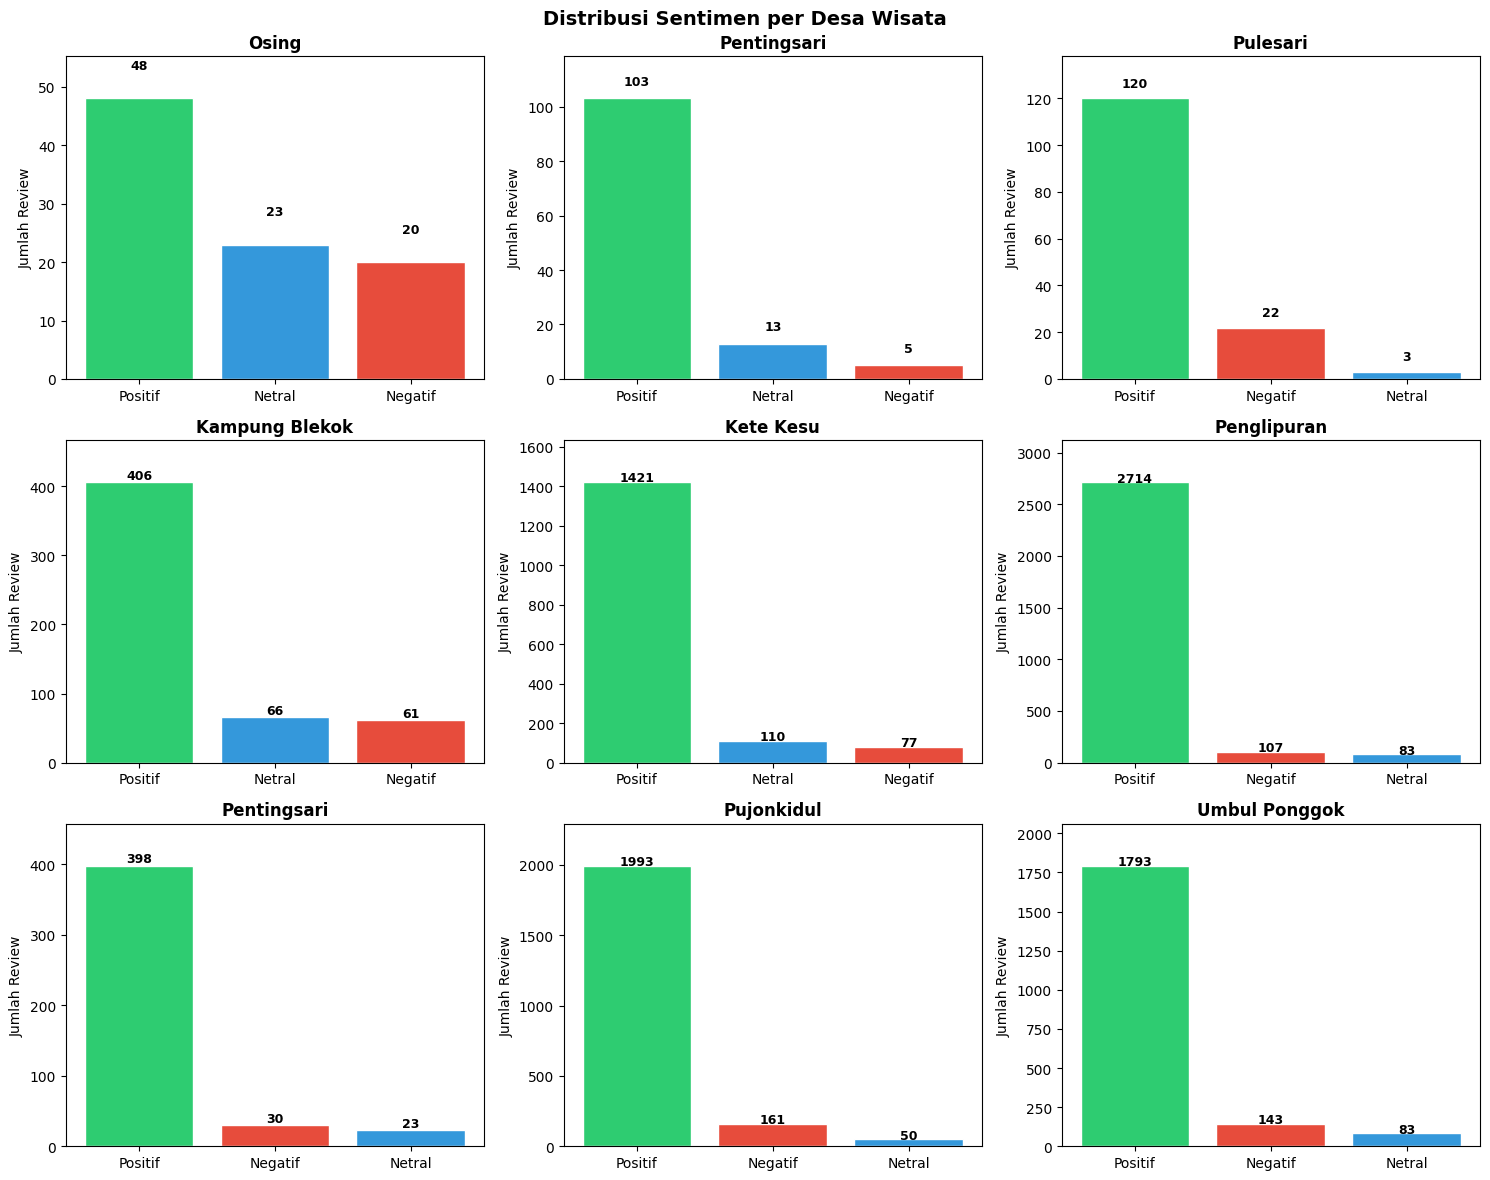

In [7]:
# Visualisasi distribusi sentimen per desa
import math
desa_list = sorted(all_df['nama desa wisata'].unique())
n_desa = len(desa_list)
ncols = 3
nrows = math.ceil(n_desa / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows))
axes = axes.flatten()

for i, desa in enumerate(desa_list):
    subset = all_df[all_df['nama desa wisata'] == desa]
    counts = subset['sentiment'].value_counts()
    bars = axes[i].bar(
        counts.index, counts.values,
        color=[COLORS.get(s, '#95a5a6') for s in counts.index],
        edgecolor='white'
    )
    for bar, val in zip(bars, counts.values):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                     str(val), ha='center', fontsize=9, fontweight='bold')
    axes[i].set_title(desa.title(), fontweight='bold')
    axes[i].set_ylabel('Jumlah Review')
    axes[i].set_ylim(0, counts.max() * 1.15)

# Hide unused subplots
for j in range(n_desa, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribusi Sentimen per Desa Wisata', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

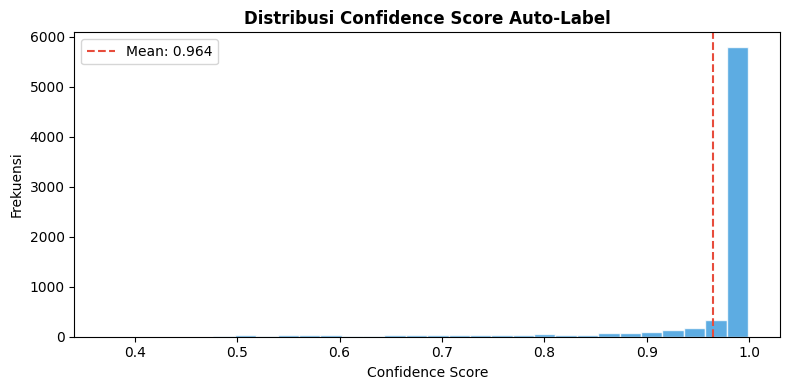

Confidence score rata-rata : 0.9643
Confidence score > 0.8     : 6748 (93.8%)
Confidence score > 0.9     : 6487 (90.2%)


In [8]:
# Confidence score distribution untuk auto-label
auto_data = all_df[all_df['label_source'] == 'auto']

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(auto_data['conf_score'], bins=30, color='#3498db', edgecolor='white', alpha=0.8)
ax.axvline(auto_data['conf_score'].mean(), color='#e74c3c', linestyle='--',
           label=f'Mean: {auto_data["conf_score"].mean():.3f}')
ax.set_xlabel('Confidence Score')
ax.set_ylabel('Frekuensi')
ax.set_title('Distribusi Confidence Score Auto-Label', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Confidence score rata-rata : {auto_data["conf_score"].mean():.4f}')
print(f'Confidence score > 0.8     : {(auto_data["conf_score"] > 0.8).sum()} ({(auto_data["conf_score"] > 0.8).mean()*100:.1f}%)')
print(f'Confidence score > 0.9     : {(auto_data["conf_score"] > 0.9).sum()} ({(auto_data["conf_score"] > 0.9).mean()*100:.1f}%)')

## 6. Simpan Output

In [9]:
# Kolom yang disimpan untuk dashboard
out_cols = ['review', 'cleaned_review', 'label', 'sentiment', 'label_source', 'conf_score', 'nama desa wisata']
out_df = all_df[out_cols].copy()

# Hapus baris tanpa review
out_df = out_df[out_df['cleaned_review'].notna() & (out_df['cleaned_review'].str.strip() != '')]

out_df.to_csv(OUT_PATH, index=False, encoding='utf-8')

print(f'Saved {len(out_df)} rows -> {OUT_PATH}')
print()
print('Final distribusi:')
print(out_df['sentiment'].value_counts())
print()
print('Summary per desa wisata:')
summary = out_df.groupby(['nama desa wisata', 'sentiment']).size().unstack(fill_value=0)
summary['Total'] = summary.sum(axis=1)
print(summary)

Saved 10076 rows -> d:\Kuliah\TA\TA_Notebook\sentiment analysis\data\sentiment_labeled.csv

Final distribusi:
sentiment
Positif    8996
Negatif     626
Netral      454
Name: count, dtype: int64

Summary per desa wisata:
sentiment         Negatif  Netral  Positif  Total
nama desa wisata                                 
Osing                  20      23       48     91
Pentingsari             5      13      103    121
Pulesari               22       3      120    145
kampung blekok         61      66      406    533
kete kesu              77     110     1421   1608
penglipuran           107      83     2714   2904
pentingsari            30      23      398    451
pujonkidul            161      50     1993   2204
umbul ponggok         143      83     1793   2019


## 7. NLP Pre-processing: Stopwords & Stemming

Setup stopwords Indonesia dan stemmer Sastrawi untuk analisis kata yang lebih bermakna.

In [10]:
# Install jika belum ada
import subprocess, sys
for pkg in ['Sastrawi', 'nltk']:
    try:
        __import__(pkg.lower() if pkg != 'Sastrawi' else 'Sastrawi')
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg])

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from collections import Counter
import re

# Sastrawi stemmer
stemmer = StemmerFactory().create_stemmer()
print('Sastrawi stemmer loaded.')
print(f'  Test: "pemandangan" -> "{stemmer.stem("pemandangan")}"')
print(f'  Test: "kebersihan" -> "{stemmer.stem("kebersihan")}"')


Sastrawi stemmer loaded.
  Test: "pemandangan" -> "pandang"
  Test: "kebersihan" -> "bersih"


In [11]:
# Indonesian stopwords (comprehensive list)
STOPWORDS_ID = {
    # Common function words
    'yang', 'dan', 'di', 'ke', 'dari', 'ini', 'itu', 'ada', 'tidak', 'dengan',
    'untuk', 'pada', 'atau', 'juga', 'sudah', 'bisa', 'saya', 'kami', 'kita',
    'tapi', 'namun', 'kalau', 'karena', 'jika', 'sangat', 'cukup', 'lebih',
    'nya', 'lagi', 'aja', 'sih', 'kan', 'pun', 'lah', 'ya', 'dong', 'deh',
    'nih', 'tuh', 'nah', 'mah', 'banget', 'sekali', 'saja', 'hanya',
    # Pronouns
    'saya', 'aku', 'kamu', 'dia', 'kami', 'kita', 'mereka', 'beliau',
    # Prepositions & conjunctions
    'oleh', 'akan', 'telah', 'bagi', 'agar', 'supaya', 'antara', 'seperti',
    'saat', 'ketika', 'sambil', 'bahwa', 'maka', 'jadi', 'meski', 'walau',
    # Verbs (very common)
    'adalah', 'ialah', 'merupakan', 'menjadi', 'punya', 'buat', 'bikin',
    'harus', 'perlu', 'boleh', 'biar', 'tetap', 'masih', 'belum', 'sedang',
    'akan', 'mau', 'ingin', 'hendak', 'coba',
    # Abbreviations / informal
    'ga', 'gak', 'nggak', 'ngga', 'gk', 'tdk', 'dg', 'yg', 'utk',
    'dgn', 'tp', 'sm', 'dr', 'pd', 'spy', 'krn', 'jg', 'org', 'lg',
    # Numbers & measure words
    'satu', 'dua', 'tiga', 'empat', 'lima', 'banyak', 'sedikit', 'semua',
    'setiap', 'tiap', 'per', 'se', 'para',
    # Domain-specific stopwords
    'desa', 'wisata', 'tempat', 'review', 'bintang',
    'google', 'maps', 'foto', 'video', 'kali', 'kalo', 'kayak', 'gimana',
    'gitu', 'sini', 'sana', 'situ', 'apa', 'siapa', 'kapan', 'dimana',
    'kenapa', 'mengapa', 'bagaimana', 'berapa', 'mana', 'hal', 'cara',
    'bgt', 'bngt', 'gt', 'gini', 'tau', 'tahu',
    # Very common but uninformative
    'apalagi', 'bahkan', 'sampai', 'hingga', 'sejak', 'selama',
    'sebelum', 'setelah', 'sesudah', 'sering', 'jarang', 'pernah',
    'tak', 'tanpa', 'sama', 'sendiri', 'lain',
}

print(f'Total stopwords: {len(STOPWORDS_ID)}')


Total stopwords: 168


## 8. Deteksi Aspek / Topik per Review

Kategorisasi aspek yang dibicarakan pengunjung menggunakan keyword matching.
Setiap review bisa memiliki >1 aspek.

In [12]:
# Definisi keyword per kategori aspek
ASPECT_KEYWORDS = {
    'Pemandangan & Alam': [
        'pemandangan', 'alam', 'sawah', 'gunung', 'sungai', 'mangrove',
        'pantai', 'air terjun', 'pohon', 'hutan', 'danau', 'laut',
        'bukit', 'taman', 'kebun', 'persawahan', 'terasering',
        'sunrise', 'sunset', 'view', 'landscape',
    ],
    'Kebersihan': [
        'bersih', 'kotor', 'sampah', 'toilet', 'kamar mandi', 'wc',
        'kebersihan', 'rapi', 'jorok', 'kumuh', 'terawat',
    ],
    'Pelayanan': [
        'pelayanan', 'ramah', 'warga', 'masyarakat', 'guide',
        'pengelola', 'staff', 'petugas', 'penjaga',
        'pelayan', 'layanan', 'sambutan',
    ],
    'Fasilitas': [
        'fasilitas', 'parkir', 'jembatan', 'gazebo', 'wifi',
        'spot foto', 'kolam', 'wahana', 'mushola',
        'playground', 'ayunan', 'gardu pandang', 'homestay',
        'penginapan', 'villa', 'cottage', 'outbound',
    ],
    'Harga & Tiket': [
        'harga', 'tiket', 'murah', 'mahal', 'biaya', 'gratis',
        'bayar', 'tarif', 'retribusi', 'terjangkau', 'worth',
    ],
    'Kuliner': [
        'makanan', 'minuman', 'kopi', 'warung', 'restoran', 'kuliner',
        'menu', 'cafe', 'makan', 'minum', 'jajanan', 'oleh-oleh',
        'souvenir', 'snack', 'kedai', 'rumah makan',
    ],
    'Suasana': [
        'suasana', 'tenang', 'sejuk', 'nyaman', 'asri', 'adem',
        'damai', 'segar', 'teduh', 'dingin', 'udara',
        'santai', 'rileks',
    ],
    'Akses & Lokasi': [
        'lokasi', 'akses', 'jarak', 'jauh', 'dekat', 'strategis',
        'jalan', 'rute', 'transportasi', 'kendaraan',
        'motor', 'mobil', 'bus', 'ojek',
    ],
    'Budaya & Tradisi': [
        'budaya', 'adat', 'tradisi', 'rumah adat', 'upacara',
        'kesenian', 'tari', 'musik', 'gamelan', 'batik',
        'kerajinan', 'sejarah', 'heritage',
    ],
}

def detect_aspects(text):
    """Deteksi aspek dari teks review. Return list of matched categories."""
    text_lower = str(text).lower()
    found = []
    for category, keywords in ASPECT_KEYWORDS.items():
        for kw in keywords:
            if kw in text_lower:
                found.append(category)
                break
    return found if found else ['Lainnya']

# Apply ke seluruh dataset
out_df['aspects'] = out_df['cleaned_review'].apply(detect_aspects)

# Statistik
all_aspects = [a for alist in out_df['aspects'] for a in alist]
aspect_counts = Counter(all_aspects)
print('Distribusi aspek (total mention):')
for asp, cnt in aspect_counts.most_common():
    pct = cnt / len(out_df) * 100
    print(f'  {asp:25s} {cnt:>6,} ({pct:.1f}%)')


Distribusi aspek (total mention):
  Suasana                    2,737 (27.2%)
  Lainnya                    2,681 (26.6%)
  Kebersihan                 2,320 (23.0%)
  Pemandangan & Alam         2,123 (21.1%)
  Harga & Tiket              1,605 (15.9%)
  Kuliner                    1,397 (13.9%)
  Budaya & Tradisi           1,360 (13.5%)
  Fasilitas                  1,345 (13.3%)
  Pelayanan                  1,314 (13.0%)
  Akses & Lokasi             1,187 (11.8%)


## 8b. Load MTL Model (Hierarchical Multi-Task ABSA)

Load model MTL terbaik (`best_model.pt`, F1=0.7410) untuk inferensi token-level BIEOS.
Model ini akan dipakai di Section 8c untuk mendapatkan sentimen per-aspek yang lebih akurat
dibanding pendekatan sentence-level dari mdhugol.

In [13]:
import torch
import torch.nn as nn
from transformers import AutoModel, AutoTokenizer
from torchcrf import CRF
import json as _json

# ── Config ──
MTL_MODEL_NAME  = 'indobenchmark/indobert-large-p2'
MTL_MODEL_PATH  = os.path.join(BASE_DIR, 'models', 'best_model.pt')
BIEOS_DATA_PATH = os.path.join(BASE_DIR, 'data', 'processed', 'train_data_bieos.json')

ate_labels   = ['O', 'B', 'I', 'E', 'S']
bieos_labels = ['O', 'B-NEG', 'B-NEU', 'B-POS', 'E-NEG', 'E-NEU', 'E-POS',
                'I-NEG', 'I-NEU', 'I-POS', 'S-NEG', 'S-NEU', 'S-POS']
ate_label2id   = {l: i for i, l in enumerate(ate_labels)}
bieos_id2label = {i: l for i, l in enumerate(bieos_labels)}
MTL_PROJ_DIM   = 256

device_mtl = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device_mtl}')

# Bebaskan VRAM dari mdhugol sebelum load model besar
try:
    del classifier, model_sa, tokenizer_sa
    import gc; gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    print('mdhugol freed from memory.')
except NameError:
    pass


# ── Definisi Model (identik dengan NB 03) ──
class CrossAttentionASD(nn.Module):
    def __init__(self, dim, max_relative_position=20):
        super().__init__()
        self.max_rel_pos    = max_relative_position
        self.pos_embedding  = nn.Embedding(2 * max_relative_position + 1, dim)
        self.W_ae  = nn.Linear(dim, dim, bias=False)
        self.W_sl  = nn.Linear(dim, dim, bias=False)
        self.W_pos = nn.Linear(dim, dim, bias=False)
        self.bias  = nn.Parameter(torch.zeros(dim))
        self.w_s   = nn.Linear(dim, 1, bias=False)

    def forward(self, h_ae, h_sl, mask=None):
        batch, seq_len, dim = h_ae.shape
        pos     = torch.arange(seq_len, device=h_ae.device)
        rel_pos = (pos.unsqueeze(0) - pos.unsqueeze(1)).clamp(
            -self.max_rel_pos, self.max_rel_pos) + self.max_rel_pos
        p_ij     = self.pos_embedding(rel_pos)
        combined = (self.W_ae(h_ae).unsqueeze(2)
                    + self.W_sl(h_sl).unsqueeze(1)
                    + self.W_pos(p_ij).unsqueeze(0)
                    + self.bias)
        scores = self.w_s(torch.tanh(combined)).squeeze(-1)
        if mask is not None:
            scores = scores.masked_fill(~mask.unsqueeze(1), float('-inf'))
        return torch.bmm(torch.softmax(scores, dim=-1), h_sl)


class HierarchicalMultiTaskABSA(nn.Module):
    def __init__(self, model_name, num_ate, num_sld, num_asd, num_final,
                 proj_dim=256, dropout=0.1, max_relative_position=20, **kwargs):
        super().__init__()
        self.num_ate = num_ate
        self.bert    = AutoModel.from_pretrained(model_name, low_cpu_mem_usage=True)
        bert_dim = self.bert.config.hidden_size
        self.ate_proj       = nn.Sequential(nn.Linear(bert_dim + num_ate, proj_dim), nn.GELU(), nn.Dropout(dropout))
        self.ate_classifier = nn.Linear(proj_dim, num_ate)
        self.sld_proj       = nn.Sequential(nn.Linear(bert_dim, proj_dim), nn.GELU(), nn.Dropout(dropout))
        self.sld_classifier = nn.Linear(proj_dim, num_sld)
        self.cross_attention = CrossAttentionASD(proj_dim, max_relative_position)
        self.asd_classifier  = nn.Linear(proj_dim, num_asd)
        self.final_proj      = nn.Sequential(nn.Linear(proj_dim * 2, proj_dim), nn.GELU(), nn.Dropout(dropout))
        self.final_emission  = nn.Linear(proj_dim, num_final)
        self.crf     = CRF(num_final, batch_first=True)
        self.dropout = nn.Dropout(dropout)

    def forward(self, input_ids, attention_mask, prior_probs=None, **kwargs):
        h = self.dropout(
            self.bert(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state)
        if prior_probs is None:
            prior_probs = torch.zeros(*h.shape[:-1], self.num_ate, device=h.device)
        h_ae  = self.ate_proj(torch.cat([h, prior_probs], dim=-1))
        h_sl  = self.sld_proj(h)
        mask  = attention_mask.bool()
        h_sd  = self.cross_attention(h_ae, h_sl, mask=mask)
        emissions = self.final_emission(self.final_proj(torch.cat([h_ae, h_sd], dim=-1)))
        return {'emissions': emissions}

    def decode(self, emissions, attention_mask):
        return self.crf.decode(emissions.float(), mask=attention_mask.bool())


# ── Build word_prior dari data training ──
print('Building word_prior ...')
with open(BIEOS_DATA_PATH, 'r', encoding='utf-8') as f:
    bieos_train = _json.load(f)

default_prior = [1.0] + [0.0] * (len(ate_labels) - 1)
word_ate_freq = {}
for sample in bieos_train:
    for tok, lab in zip(sample['tokens'], sample['labels']):
        t = tok.lower()
        if t not in word_ate_freq:
            word_ate_freq[t] = [0] * len(ate_labels)
        prefix = lab.split('-')[0] if lab != 'O' else 'O'
        word_ate_freq[t][ate_label2id[prefix]] += 1

word_prior = {
    w: [c / sum(counts) for c in counts] if sum(counts) > 0 else default_prior
    for w, counts in word_ate_freq.items()
}
print(f'word_prior: {len(word_prior)} unique words')

# ── Load tokenizer & model ──
print(f'\nLoading MTL model: {MTL_MODEL_PATH}')
tokenizer_mtl = AutoTokenizer.from_pretrained(MTL_MODEL_NAME)
model_mtl = HierarchicalMultiTaskABSA(
    model_name=MTL_MODEL_NAME,
    num_ate=len(ate_labels), num_sld=3, num_asd=4,
    num_final=len(bieos_labels),
    proj_dim=MTL_PROJ_DIM, dropout=0.1, max_relative_position=20,
).to(device_mtl)

# strict=False: aman karena key yang missing (position_ids) adalah buffer
# positional encoding bawaan transformers baru, bukan parameter yang dilatih
missing, unexpected = model_mtl.load_state_dict(
    torch.load(MTL_MODEL_PATH, map_location=device_mtl, weights_only=True),
    strict=False,
)
if missing:
    print(f'Missing keys (ignored): {missing}')
if unexpected:
    print(f'Unexpected keys: {unexpected}')

model_mtl.eval()
print('MTL model ready.')

Device: cuda
mdhugol freed from memory.
Building word_prior ...
word_prior: 4682 unique words

Loading MTL model: d:\Kuliah\TA\TA_Notebook\models\best_model.pt


d:\miniconda3\envs\ta_nlp\lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
d:\miniconda3\envs\ta_nlp\lib\site-packages\transformers\modeling_utils.py:446: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.s

Missing keys (ignored): ['bert.embeddings.position_ids']
MTL model ready.


## 8c. Inferensi MTL — Sentimen Per-Aspek

Untuk setiap review, jalankan MTL model dan ekstrak span aspek beserta sentimennya (BIEOS token-level).
Span di-map ke kategori via `ASPECT_KEYWORDS` yang sama. Hasilnya disimpan di kolom `mtl_sentiments`
untuk digunakan di Section 10 menggantikan sentence-level sentiment dari mdhugol.

In [14]:
from tqdm.auto import tqdm
from collections import Counter

MTL_SENT_MAP   = {'POS': 'Positif', 'NEG': 'Negatif', 'NEU': 'Netral'}
MTL_BATCH_SIZE = 16


def extract_bieos_spans(word_tokens, pred_labels):
    """Extract list of (span_text, sentiment) from word-level BIEOS predictions."""
    spans = []
    i = 0
    while i < len(pred_labels):
        lbl = pred_labels[i]
        if lbl == 'O' or '-' not in lbl:
            i += 1
            continue
        prefix, sentiment = lbl.split('-', 1)
        if prefix == 'S':
            spans.append((word_tokens[i], sentiment))
            i += 1
        elif prefix == 'B':
            span_toks = [word_tokens[i]]
            j = i + 1
            while j < len(pred_labels):
                nlbl = pred_labels[j]
                if '-' not in nlbl:
                    break
                nprefix, _ = nlbl.split('-', 1)
                if nprefix in ('I', 'E'):
                    span_toks.append(word_tokens[j])
                    j += 1
                    if nprefix == 'E':
                        break
                else:
                    break
            spans.append((' '.join(span_toks), sentiment))
            i = j
        else:
            i += 1
    return spans


def span_to_category(span_text):
    """Map extracted span to aspect category via keyword matching. Returns None if no match."""
    span_lower = span_text.lower()
    for category, keywords in ASPECT_KEYWORDS.items():
        for kw in keywords:
            if kw in span_lower:
                return category
    return None


def run_mtl_batch(texts, model, tokenizer, word_prior, device,
                  batch_size=16, max_length=128):
    """
    Run MTL inference on a list of cleaned_review strings.
    Returns list of dicts: {category: 'Positif'|'Negatif'|'Netral'}
    Only categories where the model extracted at least one aspect span are included.
    """
    default_p = [1.0] + [0.0] * (len(ate_labels) - 1)
    results = []

    for start in tqdm(range(0, len(texts), batch_size), desc='MTL inference', unit='batch'):
        batch_texts = texts[start:start + batch_size]
        batch_words = [str(t).lower().split() for t in batch_texts]

        enc = tokenizer(
            batch_words,
            is_split_into_words=True,
            max_length=max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt',
        )

        batch_prior = []
        for b, words in enumerate(batch_words):
            word_ids  = enc.word_ids(batch_index=b)
            prior_seq = [
                word_prior.get(words[wid], default_p) if (wid is not None and wid < len(words)) else default_p
                for wid in word_ids
            ]
            batch_prior.append(prior_seq)

        input_ids      = enc['input_ids'].to(device)
        attention_mask = enc['attention_mask'].to(device)
        prior_probs    = torch.tensor(batch_prior, dtype=torch.float).to(device)

        with torch.no_grad():
            out   = model(input_ids=input_ids, attention_mask=attention_mask,
                          prior_probs=prior_probs)
            preds = model.decode(out['emissions'], attention_mask)

        for b, words in enumerate(batch_words):
            word_ids = enc.word_ids(batch_index=b)
            pred_ids = preds[b]

            word_pred = {}
            for pos, wid in enumerate(word_ids):
                if wid is not None and wid < len(words) and wid not in word_pred:
                    word_pred[wid] = bieos_id2label[pred_ids[pos]]
            word_labels = [word_pred.get(i, 'O') for i in range(len(words))]

            spans = extract_bieos_spans(words, word_labels)

            cat_votes = {}
            for span_text, sentiment in spans:
                cat = span_to_category(span_text)
                if cat:
                    cat_votes.setdefault(cat, []).append(MTL_SENT_MAP[sentiment])

            resolved = {
                cat: Counter(sents).most_common(1)[0][0]
                for cat, sents in cat_votes.items()
            }
            results.append(resolved)

    return results


# ── Run inference ──
print(f'Running MTL inference on {len(out_df)} reviews...')
texts_for_mtl = out_df['cleaned_review'].fillna('').tolist()
mtl_results   = run_mtl_batch(
    texts_for_mtl, model_mtl, tokenizer_mtl, word_prior,
    device_mtl, batch_size=MTL_BATCH_SIZE,
)
out_df['mtl_sentiments'] = mtl_results

# ── Coverage stats ──
n_with_spans = sum(1 for r in mtl_results if r)
print(f'\nCoverage: {n_with_spans}/{len(mtl_results)} reviews '
      f'punya >=1 aspect span ({n_with_spans/len(mtl_results)*100:.1f}%)')

cat_counts = Counter()
for r in mtl_results:
    cat_counts.update(r.keys())
print('\nKategori yang diekstrak MTL:')
for cat, cnt in cat_counts.most_common():
    print(f'  {cat:25s}: {cnt:,}')

# Bebaskan VRAM
del model_mtl
import gc; gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
print('\nMTL model freed from memory.')

Running MTL inference on 10076 reviews...


MTL inference:   0%|          | 0/630 [00:00<?, ?batch/s]


Coverage: 4461/10076 reviews punya >=1 aspect span (44.3%)

Kategori yang diekstrak MTL:
  Fasilitas                : 1,093
  Pemandangan & Alam       : 1,056
  Harga & Tiket            : 967
  Suasana                  : 700
  Kuliner                  : 663
  Budaya & Tradisi         : 656
  Akses & Lokasi           : 511
  Pelayanan                : 495
  Kebersihan               : 260

MTL model freed from memory.


## 9. TF-IDF Keyword Extraction

Ekstraksi kata kunci paling distinktif per (desa, sentimen) menggunakan TF-IDF.

In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer

desa_list = sorted(out_df['nama desa wisata'].dropna().unique().tolist())
tfidf_results = {}

for desa in desa_list + ['Semua']:
    for sentiment in ['Positif', 'Negatif', 'Netral']:
        if desa == 'Semua':
            subset = out_df[out_df['sentiment'] == sentiment]
        else:
            subset = out_df[(out_df['nama desa wisata'] == desa) & (out_df['sentiment'] == sentiment)]
        
        texts = subset['cleaned_review'].dropna().tolist()
        if len(texts) < 5:
            continue
        
        tfidf = TfidfVectorizer(
            max_features=500,
            stop_words=list(STOPWORDS_ID),
            ngram_range=(1, 2),
            min_df=2,
            max_df=0.95,
        )
        X = tfidf.fit_transform(texts)
        mean_scores = X.mean(axis=0).A1
        top_idx = mean_scores.argsort()[::-1][:15]
        features = tfidf.get_feature_names_out()
        keywords = [[features[i], round(float(mean_scores[i]), 4)] for i in top_idx]
        tfidf_results[f'{desa}_{sentiment}'] = keywords

# Save
import json as _json
tfidf_path = os.path.join(os.path.dirname(OUT_PATH), 'tfidf_keywords.json')
with open(tfidf_path, 'w', encoding='utf-8') as f:
    _json.dump(tfidf_results, f, ensure_ascii=False, indent=2)
print(f'Saved TF-IDF keywords -> {tfidf_path}')
print(f'Total combinations: {len(tfidf_results)}')

# Preview
for key in list(tfidf_results.keys())[:3]:
    print(f'\n{key}:')
    for word, score in tfidf_results[key][:5]:
        print(f'  {word:25s} {score:.4f}')


Saved TF-IDF keywords -> d:\Kuliah\TA\TA_Notebook\sentiment analysis\data\tfidf_keywords.json
Total combinations: 29

Osing_Positif:
  osing                     0.0810
  banyuwangi                0.0677
  bagus                     0.0661
  ramah                     0.0614
  adat                      0.0598

Osing_Negatif:
  mandi                     0.1041
  sepi                      0.0960
  jalan                     0.0959
  kotor                     0.0940
  awat                      0.0909

Osing_Netral:
  banyuwangi                0.1570
  osing                     0.1568
  rumah                     0.1220
  adat                      0.0940
  budaya                    0.0748


## 10. Agregasi Aspek & Insight Generation

Menghasilkan file JSON ringkasan untuk dashboard: aspek summary & insight per desa.

In [16]:
import json as _json

# ── 10a. Aspect Summary (MTL-enhanced) ──
# Untuk tiap review x aspek:
#   - Jika MTL punya span yang cocok ke kategori tsb -> pakai sentimen MTL
#   - Jika tidak ada span MTL -> fallback ke sentence-level sentimen mdhugol
exploded = out_df.explode('aspects').copy()
exploded['effective_sentiment'] = exploded.apply(
    lambda row: row['mtl_sentiments'].get(row['aspects'], row['sentiment']),
    axis=1,
)

aspect_summary = {}
for desa in desa_list + ['Semua']:
    if desa == 'Semua':
        sub = exploded
    else:
        sub = exploded[exploded['nama desa wisata'] == desa]

    desa_data = {}
    for aspect in list(ASPECT_KEYWORDS.keys()) + ['Lainnya']:
        asp_sub = sub[sub['aspects'] == aspect]
        if len(asp_sub) == 0:
            continue
        sent_counts = asp_sub['effective_sentiment'].value_counts().to_dict()
        total = len(asp_sub)
        desa_data[aspect] = {
            'total':   total,
            'Positif': sent_counts.get('Positif', 0),
            'Negatif': sent_counts.get('Negatif', 0),
            'Netral':  sent_counts.get('Netral',  0),
            'positivity_rate': round(sent_counts.get('Positif', 0) / total * 100, 1) if total > 0 else 0,
        }
    aspect_summary[desa] = desa_data

asp_path = os.path.join(os.path.dirname(OUT_PATH), 'aspect_summary.json')
with open(asp_path, 'w', encoding='utf-8') as f:
    _json.dump(aspect_summary, f, ensure_ascii=False, indent=2)
print(f'Saved aspect summary (MTL-enhanced) -> {asp_path}')

# ── Coverage: berapa pairs pakai MTL vs fallback ──
non_lainnya = exploded[exploded['aspects'] != 'Lainnya']
mtl_hit = non_lainnya.apply(lambda row: row['aspects'] in row['mtl_sentiments'], axis=1)
print(f'\nMTL signal dipakai  : {mtl_hit.sum():,} / {len(mtl_hit):,} '
      f'({mtl_hit.mean()*100:.1f}%) aspect-review pairs')
print(f'Fallback ke mdhugol : {(~mtl_hit).sum():,} pairs')

print('\nSemua Desa Wisata (MTL-enhanced):')
for asp, data in sorted(aspect_summary['Semua'].items(), key=lambda x: x[1]['total'], reverse=True):
    print(f'  {asp:25s}  total={data["total"]:>5,}  '
          f'pos={data["Positif"]:>5,}  neg={data["Negatif"]:>4,}  '
          f'pos_rate={data["positivity_rate"]:>5.1f}%')

Saved aspect summary (MTL-enhanced) -> d:\Kuliah\TA\TA_Notebook\sentiment analysis\data\aspect_summary.json

MTL signal dipakai  : 6,401 / 15,388 (41.6%) aspect-review pairs
Fallback ke mdhugol : 8,987 pairs

Semua Desa Wisata (MTL-enhanced):
  Suasana                    total=2,737  pos=2,630  neg=  67  pos_rate= 96.1%
  Lainnya                    total=2,681  pos=2,323  neg= 195  pos_rate= 86.6%
  Kebersihan                 total=2,320  pos=2,077  neg= 156  pos_rate= 89.5%
  Pemandangan & Alam         total=2,123  pos=1,873  neg= 121  pos_rate= 88.2%
  Harga & Tiket              total=1,605  pos=1,119  neg= 102  pos_rate= 69.7%
  Kuliner                    total=1,397  pos=1,180  neg= 105  pos_rate= 84.5%
  Budaya & Tradisi           total=1,360  pos=1,130  neg=  33  pos_rate= 83.1%
  Fasilitas                  total=1,345  pos=  823  neg= 263  pos_rate= 61.2%
  Pelayanan                  total=1,314  pos=1,193  neg=  73  pos_rate= 90.8%
  Akses & Lokasi             total=1,187  pos=

## 10b. Audit: Span MTL yang Tidak Ter-mapping ke Kategori

Tampilkan kata yang sering muncul di review dengan MTL signal tapi tidak cocok ke keyword manapun di `ASPECT_KEYWORDS`.
Gunakan output ini untuk mempertimbangkan penambahan keyword baru.

In [17]:
# Kumpulkan kata-kata yang sering muncul di review ber-MTL tapi tidak cocok ke ASPECT_KEYWORDS
unmatched = Counter()

for text, mtl_dict in zip(out_df['cleaned_review'].fillna(''), out_df['mtl_sentiments']):
    if not mtl_dict:
        continue
    for word in str(text).lower().split():
        if word in STOPWORDS_ID or len(word) <= 3:
            continue
        if span_to_category(word) is None:
            unmatched[word] += 1

MIN_FREQ   = 10
candidates = {w: c for w, c in unmatched.items() if c >= MIN_FREQ}

print(f'Kata yang sering muncul di review ber-MTL tapi TIDAK masuk ASPECT_KEYWORDS:')
print(f'(min freq={MIN_FREQ}, total kandidat={len(candidates)})')
print()
for word, count in sorted(candidates.items(), key=lambda x: x[1], reverse=True)[:60]:
    print(f'  {word:20s} : {count:,}x')

print()
print('>> Pertimbangkan menambah kata di atas ke ASPECT_KEYWORDS yang relevan,'  )
print('   lalu re-run dari Section 8 untuk refresh aspect_summary.json.')

Kata yang sering muncul di review ber-MTL tapi TIDAK masuk ASPECT_KEYWORDS:
(min freq=10, total kandidat=812)

  bagus                : 1,096x
  masuk                : 824x
  rumah                : 549x
  bali                 : 511x
  tempatnya            : 492x
  anak                 : 427x
  indah                : 384x
  spot                 : 382x
  toraja               : 362x
  orang                : 355x
  cocok                : 324x
  enak                 : 293x
  keluarga             : 274x
  khas                 : 270x
  kesini               : 267x
  baju                 : 264x
  sewa                 : 260x
  baik                 : 249x
  salah                : 246x
  ramai                : 245x
  kurang               : 244x
  ikan                 : 236x
  luas                 : 228x
  pengunjung           : 218x
  keren                : 209x
  datang               : 199x
  airnya               : 195x
  menarik              : 194x
  cuma                 : 192x
  lumayan        

In [18]:
# ── 10b. Insight Generation per Desa ──

def get_opinion_words(df_subset, aspect, sentiment, stopwords, top_n=10):
    """Extract most common non-stopword words from reviews matching aspect+sentiment."""
    mask = df_subset['aspects'].apply(lambda x: aspect in x) & (df_subset['sentiment'] == sentiment)
    texts = df_subset.loc[mask, 'cleaned_review'].dropna().tolist()
    words = []
    for t in texts:
        for w in str(t).lower().split():
            w = re.sub(r'[^a-z]', '', w)
            if len(w) > 2 and w not in stopwords:
                words.append(w)
    return [w for w, _ in Counter(words).most_common(top_n)]

insights = {}
for desa in desa_list + ['Semua']:
    if desa == 'Semua':
        sub = out_df
    else:
        sub = out_df[out_df['nama desa wisata'] == desa]
    
    total = len(sub)
    if total == 0:
        continue
    
    sent_pct = {}
    for s in ['Positif', 'Negatif', 'Netral']:
        cnt = (sub['sentiment'] == s).sum()
        sent_pct[s] = round(cnt / total * 100, 1)
    
    asp_data = aspect_summary.get(desa, {})
    praised = sorted(
        [(k, v) for k, v in asp_data.items() if k != 'Lainnya'],
        key=lambda x: x[1].get('Positif', 0), reverse=True
    )
    top_praised = []
    for asp_name, asp_vals in praised[:3]:
        if asp_vals.get('Positif', 0) > 0:
            opinions = get_opinion_words(sub, asp_name, 'Positif', STOPWORDS_ID, 5)
            top_praised.append({'category': asp_name, 'count': asp_vals['Positif'], 'opinions': opinions})
    
    criticized = sorted(
        [(k, v) for k, v in asp_data.items() if k != 'Lainnya'],
        key=lambda x: x[1].get('Negatif', 0), reverse=True
    )
    top_criticized = []
    for asp_name, asp_vals in criticized[:3]:
        if asp_vals.get('Negatif', 0) > 0:
            opinions = get_opinion_words(sub, asp_name, 'Negatif', STOPWORDS_ID, 5)
            top_criticized.append({'category': asp_name, 'count': asp_vals['Negatif'], 'opinions': opinions})
    
    tfidf_key = f'{desa}_Positif'
    distinctive = [w for w, _ in tfidf_results.get(tfidf_key, [])[:5]]
    
    headline_pos = ''
    if top_praised:
        cats = ' dan '.join([p['category'] for p in top_praised[:2]])
        headline_pos = f'Pengunjung memuji {cats}'
    
    headline_neg = ''
    if top_criticized:
        cats = ' dan '.join([c['category'] for c in top_criticized[:2]])
        headline_neg = f'Keluhan utama terkait {cats}'
    
    insights[desa] = {
        'total_reviews': total,
        'sentiment_pct': sent_pct,
        'top_praised': top_praised,
        'top_criticized': top_criticized,
        'distinctive_keywords': distinctive,
        'headline_positive': headline_pos,
        'headline_negative': headline_neg,
    }

insights_path = os.path.join(os.path.dirname(OUT_PATH), 'insights_summary.json')
with open(insights_path, 'w', encoding='utf-8') as f:
    _json.dump(insights, f, ensure_ascii=False, indent=2)
print(f'Saved insights -> {insights_path}')

sample_desa = desa_list[0]
print(f'\n=== Insight: {sample_desa} ===')
ins = insights[sample_desa]
print(f'Total reviews: {ins["total_reviews"]}')
print(f'Sentiment: {ins["sentiment_pct"]}')
print(f'Headline (+): {ins["headline_positive"]}')
print(f'Headline (-): {ins["headline_negative"]}')
print(f'Distinctive: {ins["distinctive_keywords"]}')


Saved insights -> d:\Kuliah\TA\TA_Notebook\sentiment analysis\data\insights_summary.json

=== Insight: Osing ===
Total reviews: 91
Sentiment: {'Positif': np.float64(52.7), 'Negatif': np.float64(22.0), 'Netral': np.float64(25.3)}
Headline (+): Pengunjung memuji Budaya & Tradisi dan Pelayanan
Headline (-): Keluhan utama terkait Kebersihan dan Fasilitas
Distinctive: ['osing', 'banyuwangi', 'bagus', 'ramah', 'adat']


## 11. Update CSV dengan Kolom Aspek

In [19]:
# Convert aspects list to pipe-separated string for CSV
out_df['aspects_str'] = out_df['aspects'].apply(lambda x: '|'.join(x))

out_cols_updated = ['review', 'cleaned_review', 'label', 'sentiment',
                    'label_source', 'conf_score', 'nama desa wisata', 'aspects_str']
out_df[out_cols_updated].to_csv(OUT_PATH, index=False, encoding='utf-8')
print(f'Updated CSV with aspects column -> {OUT_PATH}')
print(f'Rows: {len(out_df)}, Columns: {out_cols_updated}')


Updated CSV with aspects column -> d:\Kuliah\TA\TA_Notebook\sentiment analysis\data\sentiment_labeled.csv
Rows: 10076, Columns: ['review', 'cleaned_review', 'label', 'sentiment', 'label_source', 'conf_score', 'nama desa wisata', 'aspects_str']


## 12. Opini per Aspek (untuk Dashboard)

Simpan top opinion words per (desa, aspek, sentimen) untuk visualisasi.

In [20]:
# Opinion words per (desa, aspect, sentiment)
opinion_data = {}
for desa in desa_list + ['Semua']:
    if desa == 'Semua':
        sub = out_df
    else:
        sub = out_df[out_df['nama desa wisata'] == desa]
    
    desa_opinions = {}
    for aspect in list(ASPECT_KEYWORDS.keys()):
        aspect_opinions = {}
        for sentiment in ['Positif', 'Negatif', 'Netral']:
            words = get_opinion_words(sub, aspect, sentiment, STOPWORDS_ID, 10)
            if words:
                aspect_opinions[sentiment] = words
        if aspect_opinions:
            desa_opinions[aspect] = aspect_opinions
    opinion_data[desa] = desa_opinions

opinion_path = os.path.join(os.path.dirname(OUT_PATH), 'opinion_words.json')
with open(opinion_path, 'w', encoding='utf-8') as f:
    _json.dump(opinion_data, f, ensure_ascii=False, indent=2)
print(f'Saved opinion words -> {opinion_path}')

# Preview
print(f'\n=== Opinion words: {desa_list[0]} ===')
for asp, sents in list(opinion_data[desa_list[0]].items())[:3]:
    print(f'  {asp}:')
    for s, words in sents.items():
        print(f'    {s}: {words[:5]}')


Saved opinion words -> d:\Kuliah\TA\TA_Notebook\sentiment analysis\data\opinion_words.json

=== Opinion words: Osing ===
  Pemandangan & Alam:
    Positif: ['baik', 'salah', 'suasana', 'tandang', 'diam']
    Negatif: ['dalam', 'kolam', 'bersih', 'kosong', 'kondisi']
    Netral: ['adat', 'dalam', 'kolam', 'renang', 'kemiren']
  Kebersihan:
    Positif: ['bersih', 'kolam', 'bayar', 'renang', 'kemiren']
    Negatif: ['kotor', 'ribu', 'awat', 'kolam', 'tiket']
  Pelayanan:
    Positif: ['ramah', 'adat', 'masyarakat', 'banyuwangi', 'makan']
    Netral: ['rumah', 'beda', 'adat', 'guide', 'lokal']
